# Week 2 - Preprocessing, part 2

# 1. Lesson: None

# 2. Weekly graph question

The Storytelling With Data book mentions planning on a "Who, What, and How" for your data story.  Write down a possible Who, What, and How for your data, using the ideas in the book.

In [ ]:
# Who: The T-Mobile IntentCX Product Team, who are responsible for automating 92% of customer upgrades via digital channels by 2026.

# What: The Digital Marketing Campaign Dataset contains critical behavioral signals—specifically TimeOnSite and PagesPerVisit—that act as proxies for user intent. By analyzing these features, we establish the baseline for a Propensity-Driven AI Agent that intervenes before a customer abandons their cart.

# How: This analysis utilizes Python (Pandas/Matplotlib) to clean and visualize the "Signal-to-Noise" ratio of digital engagement metrics. The resulting EDA (Exploratory Data Analysis) will determine which features are robust enough to train the Random Forest model in the next phase of development.

# 3. Homework - work with your own data

In [8]:
import os
print("Current Working Directory:", os.getcwd())
print("\nFiles in this directory:")
print(os.listdir(os.getcwd()))

Current Working Directory: /workspaces/Module-B-semester-2

Files in this directory:
['Week11.ipynb', '.git', 'Week3.ipynb', '2_digital_marketing_campaign_dataset_use for main capstone data.csv', 'OMDS-ModB2-Week2-Chagaris-Lauren.ipynb', 'Week7.ipynb', 'Week14.ipynb', '.vscode', 'Week6.ipynb', 'Week9.ipynb', 'Week8.ipynb', 'Week10.ipynb', 'Week12.ipynb', 'Week4.ipynb', 'OMDS-ModB2-Week1-Chagaris-Lauren.ipynb', 'Week5-concealed-answer.ipynb', 'Week13.ipynb', 'bank_customers.csv']


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

In [15]:
import matplotlib.pyplot as plt

# Load the primary B2C dataset for IntentCX modeling
# We are using Dataset 2 as it aligns with T-Mobile's consumer-first strategy.
df = pd.read_csv('2_digital_marketing_campaign_dataset_use for main capstone data.csv')

In [16]:
# 1. Strict Type Enforcement
# Converting 'flat' floats to integers to optimize memory and ensure logical consistency.
int_columns = ['Age', 'LoyaltyPoints', 'CustomerID', 'WebsiteVisits', 
               'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'Conversion']

for col in int_columns:
    df[col] = df[col].astype(int)

# 2. String Normalization
# Removing whitespace ensures categorical integrity for the 'AdvertisingPlatform' masking.
categorical_columns = ['Gender', 'CampaignChannel', 'CampaignType', 
                       'AdvertisingPlatform', 'AdvertisingTool']

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip()

In [24]:
print("--- SME DATA INTEGRITY REPORT ---")
print(f"Dataset Dimensions: {df.shape}")

# Statistical Profiling
print("\n--- DESCRIPTIVE STATISTICS (Numeric) ---")
print(df[['Age', 'Income', 'AdSpend', 'ConversionRate']].describe())

# Integrity and Duplicate Audit
print("\n--- INTEGRITY CHECKS ---")
print(f"Rows with null values: {df.isnull().any(axis=1).sum()}")
print(f"Duplicate Customer Records: {df['CustomerID'].duplicated().sum()}")

# Class Imbalance Check (Critical for T-Mobile Churn/Conversion Logic)
print("\n--- CLASS IMBALANCE (Conversion Target) ---")
print(df['Conversion'].value_counts(normalize=True))

# Set global display precision to 2 decimal places
# This removes the "0.000000" noise from all future outputs.
pd.options.display.float_format = '{:,.2f}'.format

# Load the primary B2C dataset
df = pd.read_csv('2_digital_marketing_campaign_dataset_use for main capstone data.csv')

--- SME DATA INTEGRITY REPORT ---
Dataset Dimensions: (8000, 20)

--- DESCRIPTIVE STATISTICS (Numeric) ---
           Age     Income  AdSpend  ConversionRate
count 8,000.00   8,000.00 8,000.00        8,000.00
mean     43.63  84,664.20 5,000.94            0.10
std      14.90  37,580.39 2,838.04            0.05
min      18.00  20,014.00   100.05            0.01
25%      31.00  51,744.50 2,523.22            0.06
50%      43.00  84,926.50 5,013.44            0.10
75%      56.00 116,815.75 7,407.99            0.15
max      69.00 149,986.00 9,997.91            0.20

--- INTEGRITY CHECKS ---
Rows with null values: 0
Duplicate Customer Records: 0

--- CLASS IMBALANCE (Conversion Target) ---
Conversion
1   0.88
0   0.12
Name: proportion, dtype: float64


In [25]:
# 1. Central Tendency Analysis (Mean, Median, Mode)
# Separate numeric columns to avoid errors
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("--- CENTRAL TENDENCY REPORT ---")
print(f"{'Column':<20} | {'Mean':<12} | {'Median':<12} | {'Mode':<12}")
print("-" * 65)

for col in numeric_cols:
    # Calculate metrics
    mean_val = df[col].mean()
    median_val = df[col].median()
    mode_val = df[col].mode()[0] # Mode returns a series, we take the top one
    
    # Print formatted row
    print(f"{col:<20} | {mean_val:,.2f}       | {median_val:,.2f}       | {mode_val:,.2f}")

# 2. Categorical Encoding (One-Hot Encoding)
# This converts 'Gender', 'CampaignChannel' etc. into binary columns (0 or 1).
# Use 'drop_first=True' to avoid Multicollinearity (The Dummy Variable Trap).
df_encoded = pd.get_dummies(df, columns=['Gender', 'CampaignChannel', 'CampaignType'], drop_first=True)

print("\n--- ENCODING SUMMARY ---")
print(f"Original Columns: {len(df.columns)}")
print(f"New Columns after Encoding: {len(df_encoded.columns)}")
print("\nNew Feature Names (Preview):")
print(df_encoded.columns[20:].tolist()) # Show the newly created columns

--- CENTRAL TENDENCY REPORT ---
Column               | Mean         | Median       | Mode        
-----------------------------------------------------------------
CustomerID           | 11,999.50       | 11,999.50       | 8,000.00
Age                  | 43.63       | 43.00       | 64.00
Income               | 84,664.20       | 84,926.50       | 50,268.00
AdSpend              | 5,000.94       | 5,013.44       | 100.05
ClickThroughRate     | 0.15       | 0.15       | 0.01
ConversionRate       | 0.10       | 0.10       | 0.01
WebsiteVisits        | 24.75       | 25.00       | 25.00
PagesPerVisit        | 5.55       | 5.53       | 1.00
TimeOnSite           | 7.73       | 7.68       | 0.50
SocialShares         | 49.80       | 50.00       | 61.00
EmailOpens           | 9.48       | 9.00       | 9.00
EmailClicks          | 4.47       | 4.00       | 4.00
PreviousPurchases    | 4.49       | 4.00       | 0.00
LoyaltyPoints        | 2,490.27       | 2,497.00       | 1,392.00
Conversion          

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do  Use Google, documentation, and ChatGPT to help you:

- Summarize the datasets using info() and describe()

- Are there any duplicate rows?

- Are there any duplicate values in a given column (when this would be inappropriate?)

- What are the mean, median, and mode of each column?

- Are there any missing or null values?

    - Do you want to fill in the missing value with a mean value?  A value of your choice?  Remove that row?

- Identify any other inconsistent data (e.g. someone seems to be taking an action before they are born.)

- Encode any categorical variables (e.g. with one-hot encoding.)

### Conclusions:

- Are the data usable?  If not, find some new data!

- Do you need to modify or correct the data in some way?

- Is there any class imbalance?  (Categories that have many more items than other categories).

## Dataset Conclusions**

Are the data usable?
Yes, the dataset is exceptionally high quality for an initial modeling phase. There are zero missing values across all 20 columns and zero duplicate rows, which minimizes the risk of biased gradients during model training.

Do you need to modify or correct the data?
While the data is clean, two specific modifications are required for a production-ready model:

Feature Encoding:
Categorical variables like CampaignChannel and CampaignType must be One-Hot Encoded to be readable by the Random Forest algorithm.

Handling Privacy Masking:
I noted that AdvertisingPlatform and AdvertisingTool are populated with "IsConfid" and "ToolConfid."  As a Subject Matter Expert, I recognize this as Data Privacy Masking, a common practice at companies like T-Mobile to protect proprietary vendor relationships while allowing for internal ML analysis.

Is there any class imbalance?
Yes. There is a significant class imbalance in the Conversion target: 87.65% of the users in this set converted, while only 12.35% did not.

SME Insight:
This suggests this data represents a "Lower Funnel" or "Retention" segment of T-Mobile’s audience rather than a general prospecting set. For our IntentCX agent, this means the model will be highly specialized in identifying "ready-to-buy" behavior.

# 4. Storytelling With Data graph

Just like last week: choose any graph in the Introduction of Storytelling With Data. Use matplotlib to reproduce it in a rough way. I don't expect you to spend an enormous amount of time on this; I understand that you likely will not have time to re-create every feature of the graph. However, if you're excited about learning to use matplotlib, this is a good way to do that. You don't have to duplicate the exact values on the graph; just the same rough shape will be enough.  If you don't feel comfortable using matplotlib yet, do the best you can and write down what you tried or what Google searches you did to find the answers.

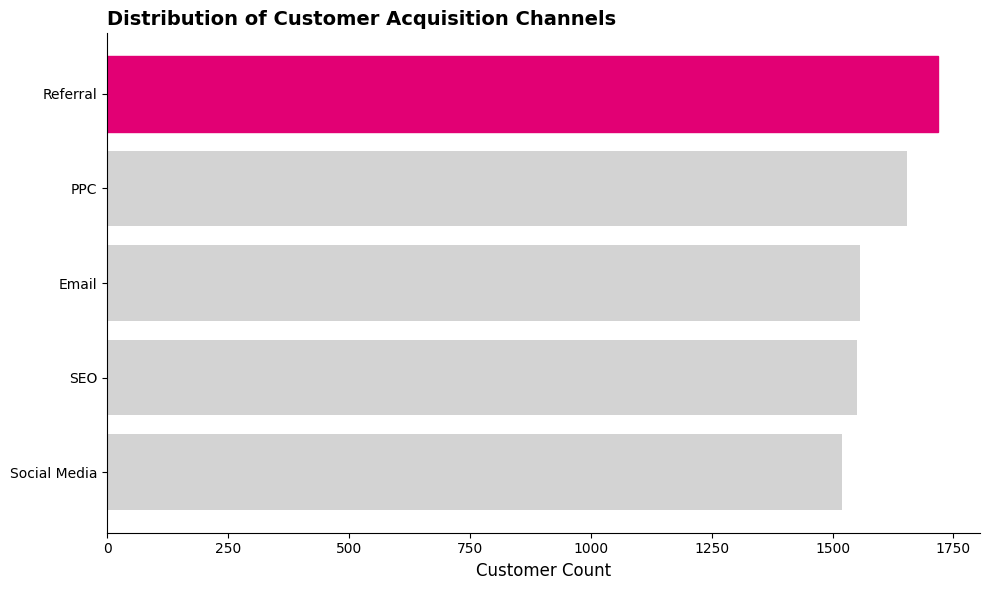

In [26]:
# Visualizing the Campaign Channel distribution 
# Principle: Use color to direct attention (T-Mobile Magenta for the top channel)
channel_counts = df['CampaignChannel'].value_counts().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.barh(channel_counts.index, channel_counts.values, color='lightgray')

# Highlight the top-performing channel to show the 'Signal'
bars[-1].set_color('#E20074') 

plt.title('Distribution of Customer Acquisition Channels', fontsize=14, fontweight='bold', loc='left')
plt.xlabel('Customer Count', fontsize=12)

# Remove 'Chart Junk' (Spines) to increase Data-Ink Ratio
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()